# <center> DS_PROD-4 практика. 
# <center> АНАЛИЗ ЭФФЕКТИВНОСТИ ДВУХ ВАРИАНТОВ ПОСАДОЧНОЙ СТРАНИЦЫ

## <center> Описание проекта и постановка задачи
Компания планирует запустить новую акцию, чтобы продать как можно больше туров. Команда разработала два варианта посадочной страницы официального сайта и провела A/B-тестирование. В результате эксперимента были собраны данные. Основная задача - проанализировать эффективность обоих вариантов посадочной страницы сразу по двум критериям — конверсии покупки и ежедневному среднему чеку.

In [172]:
#Импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportions_chisquare
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import t
from scipy.stats import norm

In [173]:
#Читаем данные
data = pd.read_csv('data/ab_data_tourist.zip')
data.head()

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
2,661590,2021-01-11,B,0,0
3,853541,2021-01-08,B,0,0
4,864975,2021-01-21,A,1,150000


#### Обозначение столбцов:
* user_id — идентификатор пользователя, зашедшего на сайт;
* data — дата посещения сайта;
* group — группа теста (контрольная — А или тестовая — B);
* purchase — признак покупки: совершил ли пользователь покупку тура (1 — да, 0 — нет);
* price — цена купленного тура (если покупка не состоялась, цена равна 0).

## <center> Загрузка данных, краткий EDA и подготовка данных к проведению A/B тестирования

In [174]:
#Посмотрим на предмет пропусков и типов данных
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   user_id   294478 non-null  int64 
 1   date      294478 non-null  object
 2   group     294478 non-null  object
 3   purchase  294478 non-null  int64 
 4   price     294478 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 11.2+ MB


In [175]:
#Краткая статистическая информация о данных
data.describe()

,user_id,purchase,price
count,294478.000000,294478.000000,294478.000000
mean,787974.124733,0.119659,10154.782361
std,91210.823776,0.324563,35153.824872
min,630000.000000,0.000000,0.000000
25%,709032.250000,0.000000,0.000000
50%,787933.500000,0.000000,0.000000
75%,866911.750000,0.000000,0.000000
max,945999.000000,1.000000,200000.000000


In [176]:
#Преобразование даты к дэйттайму
data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d')
display(data.head(2))
display(data.info())

#Делю на группы
group_a = data[data['group']=='A']
group_b = data[data['group']=='B']
display(group_a.head(3))

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   user_id   294478 non-null  int64         
 1   date      294478 non-null  datetime64[ns]
 2   group     294478 non-null  object        
 3   purchase  294478 non-null  int64         
 4   price     294478 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 11.2+ MB


None

,user_id,date,group,purchase,price
0,851104,2021-01-21,A,0,0
1,804228,2021-01-12,A,0,0
4,864975,2021-01-21,A,1,150000


Посмотрим на предмет пересечения пользователей в группах.

In [177]:
#Временная переменная
temp = pd.merge(left=group_a, right=group_b, how='inner', on='user_id')
print('Пользователи, попавшие в обе группы:')
display(temp.head(3))

#Проверю правильность метода
display(group_a[group_a['user_id']==767017])
display(group_b[group_b['user_id']==767017])
print('Пользователей, присутствующих в обеих группах:', temp['user_id'].nunique())

Пользователи, попавшие в обе группы:


,user_id,date_x,group_x,purchase_x,price_x,date_y,group_y,purchase_y,price_y
0,767017,2021-01-12,A,0,0,2021-01-08,B,0,0
1,733976,2021-01-11,A,0,0,2021-01-05,B,0,0
2,670052,2021-01-07,A,0,0,2021-01-04,B,1,150000


,user_id,date,group,purchase,price
22,767017,2021-01-12,A,0,0


,user_id,date,group,purchase,price
277989,767017,2021-01-08,B,0,0


Пользователей, присутствующих в обеих группах: 1895


Как видим, у нас есть пользователи, присутствующие в обеих группах. Необходимо от них избавиться.

In [178]:
#Поиск дубликатов
dupl_columns = list(data.columns)

mask = data.duplicated(subset=dupl_columns)
duplicates = data[mask]
print(f'Число дубликатов: {duplicates.shape[0]}')

Число дубликатов: 74


Также у нас имеется небольшое количество дубликатов. От них тоже лучше избавиться.

In [179]:
#Убираю повторяющихся пользователей
users_to_delete = temp['user_id'].tolist()
data_new = data.copy()

data_new['user_id'] = data_new['user_id'].apply(lambda x: None if x in users_to_delete else x)
data_new = data_new.dropna(how='any')

#Удаление дубликатов
dedupped = data_new.drop_duplicates(subset=dupl_columns)
data_new = dedupped

print(data.shape, data_new.shape)


#Снова делю на группы
group_a = data_new[data_new['group']=='A']
group_b = data_new[data_new['group']=='B']

#Проверю правильность метода
display(group_a[group_a['user_id']==767017])
display(group_b[group_b['user_id']==767017])

(294478, 5) (290614, 5)


,user_id,date,group,purchase,price


,user_id,date,group,purchase,price


Готово. Итого у нас примерно на 4 тысячи сделок меньше. Теперь посмотрю, совпадают ли даты тестирования в группах. Заодно сгруппирую данные по дате, может пригодится

In [180]:
a_grouped_by_date = group_a.groupby(by='date').agg({'purchase': 'sum', 'price':'sum', 'user_id':'count'})
b_grouped_by_date = group_b.groupby(by='date').agg({'purchase': 'sum', 'price':'sum', 'user_id':'count'})
print('Группа А:')
display(a_grouped_by_date.head(2), a_grouped_by_date.tail(2))
print('Группа Б:')
display(b_grouped_by_date.head(2), b_grouped_by_date.tail(2))
print('Дней наблюдений в группе А:', a_grouped_by_date.shape[0])
print('Дней наблюдений в группе Б:', b_grouped_by_date.shape[0])

#Проверка методом слияния выборок
temp = pd.merge(left=a_grouped_by_date, right=b_grouped_by_date, on=a_grouped_by_date.index, how='inner')
print('Одинаковых дат в данных:', temp.shape[0])

#Проверка дат прямым сравнением
date_list_a = a_grouped_by_date.index.tolist()
date_list_b = b_grouped_by_date.index.tolist()
print('Равны ли даты в выборках?', date_list_a==date_list_b)

Группа А:


,purchase,price,user_id
date,,,
2021-01-02,359,29410000,2854
2021-01-03,748,62000000,6595


,purchase,price,user_id
date,,,
2021-01-23,843,70950000,6697
2021-01-24,444,33250000,3765


Группа Б:


,purchase,price,user_id
date,,,
2021-01-02,345,29660000,2861
2021-01-03,754,65960000,6619


,purchase,price,user_id
date,,,
2021-01-23,805,68930000,6632
2021-01-24,442,38650000,3677


Дней наблюдений в группе А: 23
Дней наблюдений в группе Б: 23
Одинаковых дат в данных: 23
Равны ли даты в выборках? True


Даты совпали. Значит, дополнительная обработка не требуется.  

## <center> Первичный анализ результатов A/B-тестирования
Теперь рассчитаем вспомогательные показатели для контрольной и тестовой групп. Сразу же в эту таблицу добавим средний чек и конверсию.

In [181]:
#Получаем вспомогательные данные
data_new_grouped = data_new.groupby(by='group').agg({'purchase': 'sum', 'price':'sum', 'user_id':'count'}).rename(columns={'price':'total_money'})
data_new_grouped['conversion'] = data_new_grouped['purchase']/data_new_grouped['user_id']
data_new_grouped['mean_receipt'] = round(data_new_grouped['total_money']/data_new_grouped['purchase'], 2)
data_new_grouped

,purchase,total_money,user_id,conversion,mean_receipt
group,,,,,
A,17487,1417780000,145268,0.120378,81076.23
B,17290,1533010000,145346,0.118958,88664.55


На первый взгляд - тестовый вариант страницы (Выборка Б) предпочтительнее. У него совсем немного ниже конверсия, но почти на 10% выше средний чек. Количество тестируемых пользователей отличается на погрешность, данных достаточно - поэтому результат должен быть более-менее точным.

Подробнее посмотрим, куда была совершена покупка. Для этого добавим дополнительный столбец в таблицу с данными. Для удобства.

,user_id,date,group,purchase,price,tour
4,864975.0,2021-01-21,A,1,150000,Камчатка
6,679687.0,2021-01-19,B,1,10000,Санкт-Петербург
8,817355.0,2021-01-04,B,1,60000,Турция
9,839785.0,2021-01-15,B,1,10000,Санкт-Петербург
15,644214.0,2021-01-22,A,1,100000,Тайланд


price  user_id
group tour                               
A     unknown                  0   127781
      Камчатка         521700000     3478
      Мальдивы         344800000     1724
      Санкт-Петербург   51820000     5182
      Тайланд          183200000     1832
      Турция           316260000     5271
B     unknown                  0   128056
      Камчатка         515700000     3438
      Мальдивы         338800000     1694
      Санкт-Петербург   52010000     5201
      Тайланд          522700000     5227
      Турция           103800000     1730

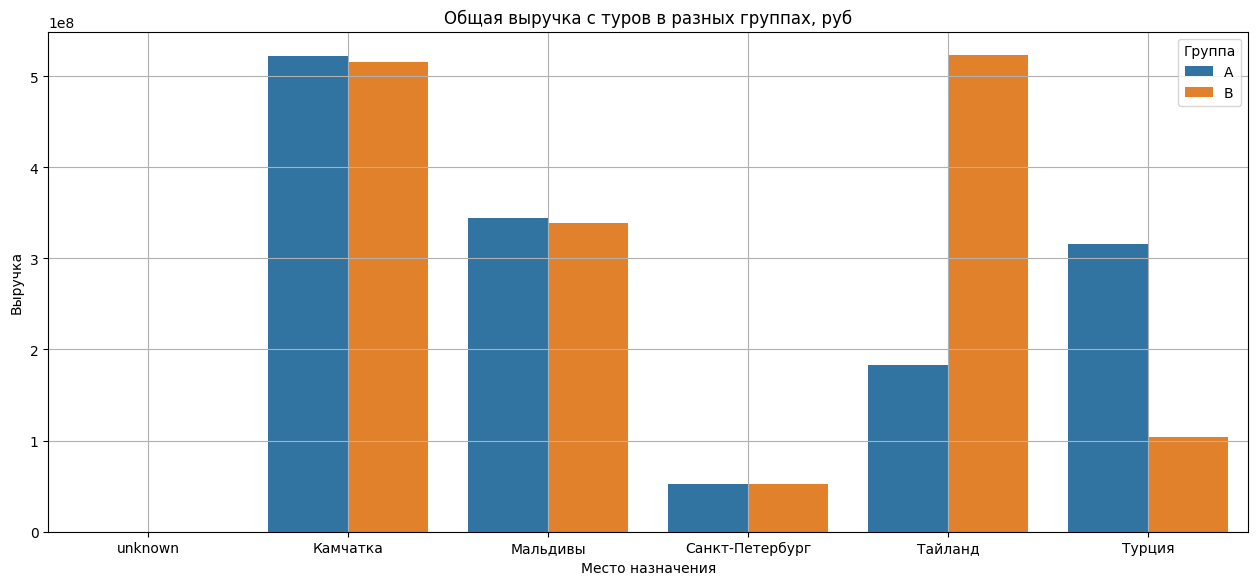

In [182]:
#Словарь с турами. Цена:место.
tour_dict = {100000:'Тайланд', 60000:'Турция', 200000:'Мальдивы', 10000:'Санкт-Петербург', 150000:'Камчатка'}

data_new['tour'] = data_new['price'].apply(lambda x: tour_dict[x] if x in tour_dict else 'unknown')

#Проверка
display(data_new[data_new['purchase']==1].head())

data_grouped_by_tour = data_new.groupby(by=['group', 'tour']).agg({'price':'sum', 'user_id':'count'})
display(data_grouped_by_tour)

#график выручки в зависимости от тура
fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.barplot(data=data_grouped_by_tour, x='tour', y='price', hue='group')
plt.xlabel('Место назначения')
plt.ylabel('Выручка')
plt.legend(title='Группа')
ax.set_title('Общая выручка с туров в разных группах, руб')
ax.grid(True);

Итого, у нас есть таблица и график выручки с каждого тура обеих групп во время тестирования. Туры на Камчатку, Мальдивы и в Санкт-Петербург по выручке ничем не выделяются, почти паритет в обеих группах. Зато группа А примерно в 3 раза чаще покупает туры в Турцию, а группа Б - в Тайланд. Туры в Тайланд дороже, скорее всего и отсюда разница в итоговой выручке в группах за все туры в период тестирования.

## <center> Анализ данных на предмет стабильности метрик
Посмотрим на метрики в течении дня. Для этого можно воспользоваться таблицами, сформированными в начале при проверке соответствия дат в группах, но для удобства визуализации я создам объединенную таблицу заново.

In [183]:
#Группируем по дате и группе
daily_data = data_new.groupby(by=['date','group']).agg({'purchase': 'sum', 'price':'sum', 'user_id':'count'}).rename(columns={'user_id':'entries'})

#Добавляем признаки конверсии и ежедневном среднем чеке
daily_data['conversion'] = daily_data['purchase']/daily_data['entries']
daily_data['daily_avg_receipt'] = round(daily_data['price']/daily_data['purchase'], 2)

#Также кумулятивные показатели: кумулятивные посещение страницы, количество покупок, сумму покупок
daily_data['cum_entries'] = daily_data.groupby(by='group')['entries'].cumsum()
daily_data['cum_purchases'] = daily_data.groupby(by='group')['purchase'].cumsum()
daily_data['cum_prices'] = daily_data.groupby(by='group')['price'].cumsum()

#Вычисление кумулятивного среднего чека и кумулятивной конверсии
daily_data['cum_conversion'] = daily_data['cum_purchases']/daily_data['cum_entries']
daily_data['cum_avg_receipt'] = round(daily_data['cum_prices']/daily_data['cum_purchases'], 2)

daily_data

purchase     price  entries  conversion  daily_avg_receipt  \
date       group                                                               
2021-01-02 A           359  29410000     2854    0.125788           81922.01   
           B           345  29660000     2861    0.120587           85971.01   
2021-01-03 A           748  62000000     6595    0.113419           82887.70   
           B           754  65960000     6619    0.113914           87480.11   
2021-01-04 A           799  64250000     6564    0.121725           80413.02   
           B           764  68030000     6534    0.116927           89044.50   
2021-01-05 A           790  64550000     6431    0.122842           81708.86   
           B           749  63550000     6509    0.115071           84846.46   
2021-01-06 A           764  63410000     6603    0.115705           82997.38   
           B           838  75020000     6748    0.124185           89522.67   
2021-01-07 A           795  67290000     6579    0.120839           84641.51   
           B           767  67170000     6613    0.115984           87574.97   
2021-01-08 A           798  65380000     6685    0.119372           81929.82   
           B           812  71270000     6712    0.120977           87770.94   
2021-01-09 A           794  65610000     6631    0.119741           82632.24   
           B           784  71410000     6625    0.118340           91084.18   
2021-01-10 A           759  58950000     6656    0.114032           77667.98   
           B           846  78080000     6701    0.126250           92293.14   
2021-01-11 A           797  58760000     6699    0.118973           73726.47   
           B           770  66960000     6678    0.115304           86961.04   
2021-01-12 A           795  68460000     6537    0.121615           86113.21   
           B           807  70560000     6633    0.121664           87434.94   
2021-01-13 A           764  63590000     6563    0.116410           83232.98   
           B           720  65910000     6493    0.110889           91541.67   
2021-01-14 A           825  65890000     6542    0.126108           79866.67   
           B           792  68990000     6608    0.119855           87108.59   
2021-01-15 A           806  67570000     6698    0.120334           83833.75   
           B           747  69160000     6562    0.113837           92583.67   
2021-01-16 A           808  66210000     6598    0.122461           81943.07   
           B           786  70560000     6541    0.120165           89770.99   
2021-01-17 A           809  63020000     6618    0.122242           77898.64   
           B           831  75300000     6545    0.126967           90613.72   
2021-01-18 A           812  62850000     6509    0.124750           77401.48   
           B           822  72240000     6599    0.124564           87883.21   
2021-01-19 A           790  63680000     6581    0.120043           80607.59   
           B           772  67820000     6562    0.117647           87849.74   
2021-01-20 A           749  58710000     6529    0.114719           78384.51   
           B           790  69250000     6684    0.118193           87658.23   
2021-01-21 A           851  70300000     6748    0.126111           82608.70   
           B           760  69870000     6555    0.115942           91934.21   
2021-01-22 A           788  63690000     6586    0.119648           80824.87   
           B           787  68660000     6655    0.118257           87242.69   
2021-01-23 A           843  70950000     6697    0.125877           84163.70   
           B           805  68930000     6632    0.121381           85627.33   
2021-01-24 A           444  33250000     3765    0.117928           74887.39   
           B           442  38650000     3677    0.120207           87443.44   

                  cum_entries  cum_purchases  cum_prices  cum_conversion  \
date       group                                                           
2021-01-02 A             

Получилось довольно громозско, но детально. Построим графики последних двух столбцов для лучшего восприятия для оценки стабильности.

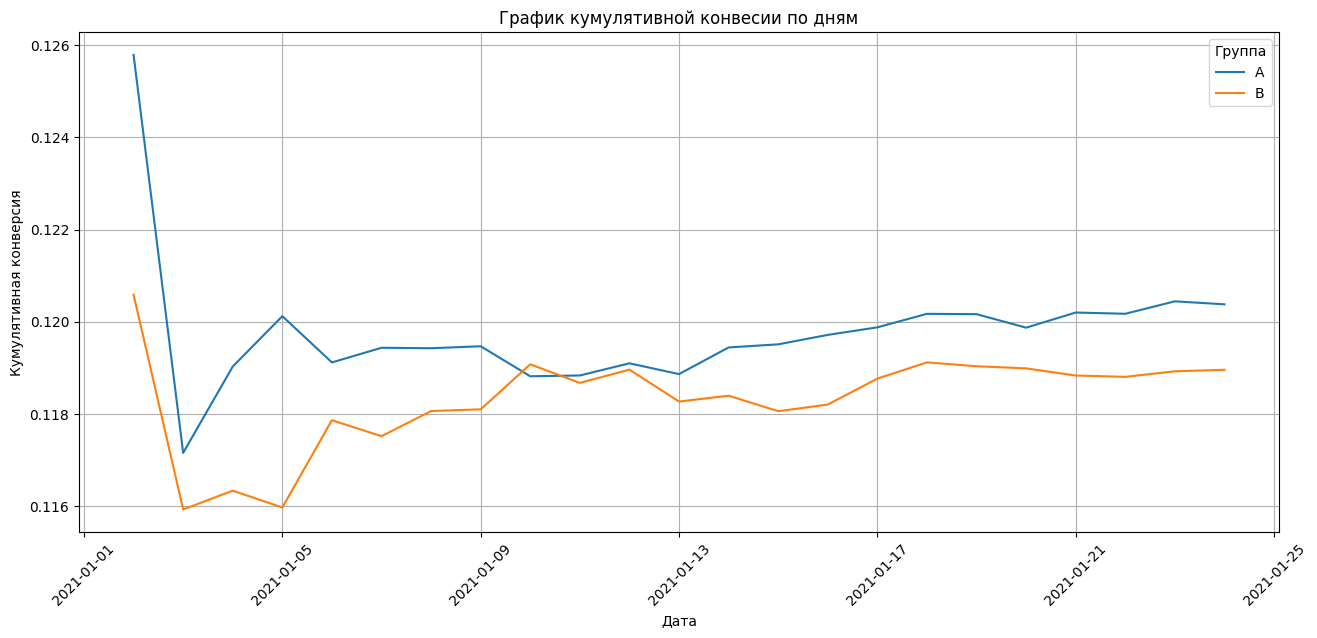

In [184]:
#График кумулятивной конверсии
fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.lineplot(data=daily_data, x='date', y='cum_conversion', hue='group', ax=ax)
plt.xlabel('Дата')
plt.ylabel('Кумулятивная конверсия')
plt.legend(title='Группа')
ax.set_title('График кумулятивной конвесии по дням')
ax.xaxis.set_tick_params(rotation=45)
ax.grid(True);

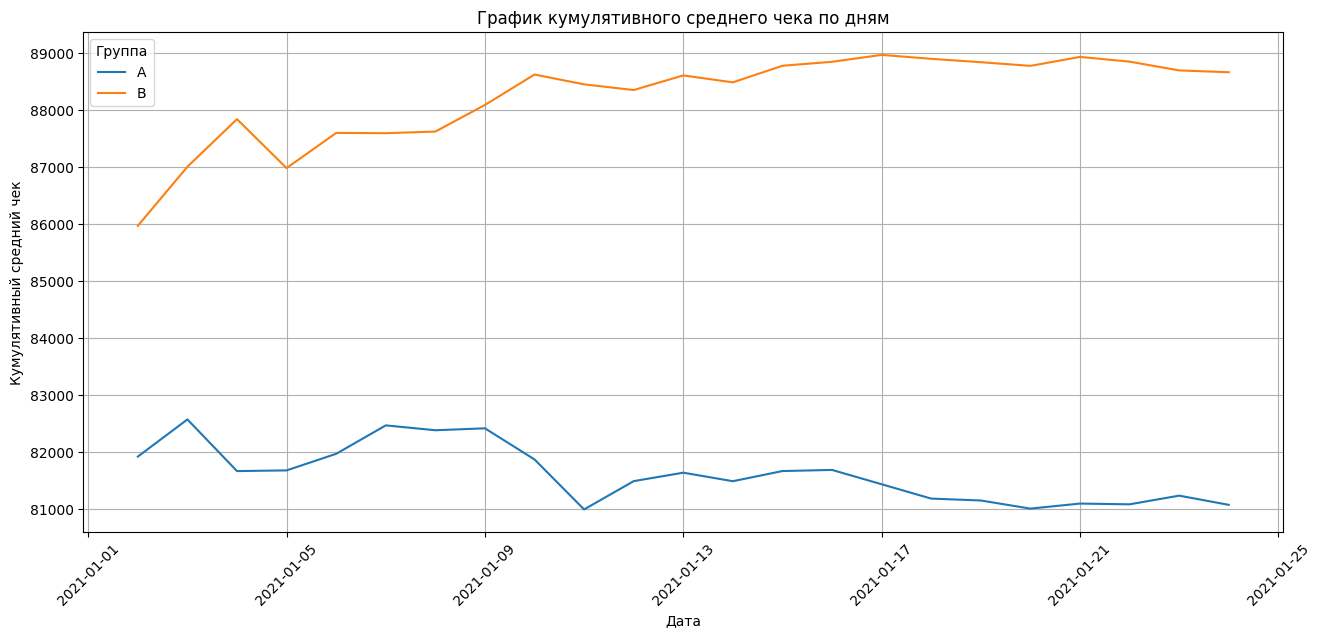

In [185]:
#График кумулятивного среднего чека
fig = plt.figure(figsize=(12,5))
ax = fig.add_axes([1,1,1,1])
sns.lineplot(data=daily_data, x='date', y='cum_avg_receipt', hue='group', ax=ax)
plt.xlabel('Дата')
plt.ylabel('Кумулятивный средний чек')
plt.legend(title='Группа')
ax.set_title('График кумулятивного среднего чека по дням')
ax.xaxis.set_tick_params(rotation=45)
ax.grid(True);

Что теперь можно сказать? Во времени кумулятивные показатели стабилизируются, и даже можно сказать 'ходят' друг за другом, то есть нечто вроде зависимости, видимо, от дня недели или чего-то такого. Также можно сказать, что устные выводы общей по сгруппированной таблице с конверсией и средним чеком подтверждаются: контрольная группа (А) имеет большую (на погрешность) конверсию, но меньше приносит оборота, и наоборот с тестовой группой (Б). Имеет смысл посмотреть дальше, так как однозначного вывода, какой вариант лучше, получается, пока нет.

## <center> Статистический анализ результатов A/B тестирования
Для начала проверим правильность выводов о конверсии с помощью z-теста. Данные будем брать из таблицы, по который мы смотрели общую сводку сгруппированных данных. Там достаточно информации для теста.

In [186]:
alpha = 0.05 # уровень значимости
# вычисляем значение p-value для Z-теста для пропорций
_, p_value = proportions_ztest(
    count=data_new_grouped['purchase'], # число «успехов»
    nobs=data_new_grouped['user_id'], # общее число наблюдений
    alternative='two-sided' # нулевая гипотеза - конверсии выборок равны
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.238
У нас нет оснований отвергнуть нулевую гипотезу


In [187]:
alpha = 0.05 # уровень значимости
# вычисляем значение p-value для Z-теста для пропорций
_, p_value = proportions_ztest(
    count=data_new_grouped['purchase'], # число «успехов»
    nobs=data_new_grouped['user_id'], # общее число наблюдений
    alternative='larger' #нулевая гипотеза - конверсия контрольной 
                         #группы (А) меньше или равна конверсии тестовой 
                         #группы (Б)
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.119
У нас нет оснований отвергнуть нулевую гипотезу


Судя по этому тесту, статистической разницы в конверсиях нет или она незначительная для бизнеса. На всякий случай воспользуемся другим тестом - хи-квадрат. Просто проверим уже выдвигаемую ранее нулевую гипотезу о равности.

In [188]:
alpha = 0.05 # уровень значимости
# По умолчанию выдвигается нулевая гипотеза о равности
_, p_value, c = proportions_chisquare(
    count=data_new_grouped['purchase'], # число «успехов»
    nobs=data_new_grouped['user_id'], # общее число наблюдений
)
# выводим результат на экран
print('p-value: ', round(p_value, 3))
# сравниваем полученное p-value с уровнем значимости
if (p_value <= alpha):
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value:  0.238
У нас нет оснований отвергнуть нулевую гипотезу


Результат схожий. Идём далее - необходимо узнать статистическую разницу между средними чеками каждой из групп. У нас есть 2 независимые друг от друга группы, которые скорее всего не распределены по нормальному закону. Поэтому нам подойдёт критерий манна-уитни. Но нормальность распределения лучше проверить по тесту Шапиро-Уилка. Данные уже будем использовать из сгруппированной по дням таблицы.

In [189]:
#Предварительно для удобства разделю данные на 2 таблицы
daily_data_a = daily_data[daily_data.index.get_level_values('group')=='A']
daily_data_b = daily_data[daily_data.index.get_level_values('group')=='B']

display(daily_data_a.head(2))
display(daily_data_b.head(2))

,,purchase,price,entries,conversion,daily_avg_receipt,cum_entries,cum_purchases,cum_prices,cum_conversion,cum_avg_receipt
date,group,,,,,,,,,,
2021-01-02,A,359,29410000,2854,0.125788,81922.01,2854,359,29410000,0.125788,81922.01
2021-01-03,A,748,62000000,6595,0.113419,82887.70,9449,1107,91410000,0.117155,82574.53


,,purchase,price,entries,conversion,daily_avg_receipt,cum_entries,cum_purchases,cum_prices,cum_conversion,cum_avg_receipt
date,group,,,,,,,,,,
2021-01-02,B,345,29660000,2861,0.120587,85971.01,2861,345,29660000,0.120587,85971.01
2021-01-03,B,754,65960000,6619,0.113914,87480.11,9480,1099,95620000,0.115928,87006.37


In [190]:
#На всякий случай

alpha = 0.05 # уровень значимости
# вычисляем результат теста Шапиро — Уилка для выборок
shapiro_result_a = shapiro(daily_data_a['daily_avg_receipt'])
shapiro_result_b = shapiro(daily_data_b['daily_avg_receipt'])
print('p-value группы А', round(shapiro_result_a.pvalue, 2))
print('p-value группы B', round(shapiro_result_b.pvalue, 2))

# сравниваем полученное p-value для группы А с уровнем значимости
if shapiro_result_a.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе А отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе А является нормальным")

# сравниваем полученное p-value для группы B с уровнем значимости
if shapiro_result_b.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной. Распределение в группе B отлично от нормального")
else:
    print("Принимаем нулевую гипотезу. Распределение в группе B является нормальным")

p-value группы А 0.25
p-value группы B 0.09
Принимаем нулевую гипотезу. Распределение в группе А является нормальным
Принимаем нулевую гипотезу. Распределение в группе B является нормальным


Распределения в обеих группах оказались нормальными. Это меняет дело, поэтому воспользуемся другим тестом - двухвыборочным t-критерием.

In [191]:
alpha = 0.05 #уровень значимости
# вычисляем результат T-теста для выборок
results = ttest_ind(
    a=daily_data_a['daily_avg_receipt'],
    b=daily_data_b['daily_avg_receipt'],
    alternative='two-sided'  #Нулевая гипотеза - средние чеки равны
)
print('p-value:', round(results.pvalue, 2))

# сравниваем полученное p-value с уровнем значимости
if results.pvalue <= alpha:
    print("Отвергаем нулевую гипотезу в пользу альтернативной")
else:
    print("У нас нет оснований отвергнуть нулевую гипотезу")

p-value: 0.0
Отвергаем нулевую гипотезу в пользу альтернативной


Тест показал, что между чеками групп имеется явная разница. Это подтверждает выводы, сделанные ранее - средний чек в группе Б больше.

На всякий случай подкрепим вывод, построив 95% доверительные интервалы для конверсий и ежедневного чека каждой из групп с помощью функций, приведённых в юнитах на платформе. Встроенные аналоги в библиотеках в этот раз не используются. Стандартное отклонение нам нигде не известно, потому функциями, связанными с ним, пользоваться не буду. 

In [192]:
#Необходимые функции

def proportion_conf_interval(x_p, n, gamma=0.95):  
    
    """
    Функция расчета доверительного интервала для пропорций.
    Возвращает кортеж - левую и правую (нижнюю и верхнюю) границу.

    Args:
        x_p (series of ints): выборочная пропорция
        n (int): размер выборки
        gamma (float, optional): уровень надёжности. Defaults to 0.95.
    """    
    
    alpha = 1 - gamma # уровень значимости
    z_crit = -norm.ppf(alpha/2) # z-критическое
    eps = z_crit * (x_p * (1 - x_p) / n) ** 0.5 # погрешность
    lower_bound = x_p - eps # левая (нижняя) граница
    upper_bound = x_p + eps # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    return lower_bound, upper_bound


def diff_proportion_conf_interval(x_p, n, gamma=0.95):
    
    """Функция для расчёта доверительного интервала разницы пропорций.
    Возвращает нижнюю (левую) и верхнюю (правую) границу.

    Args:
        x_p (list): Список из выборочных конверсий групп. Порядок важен.
        n (list): Список с количеством элементов в каждой выборке. 
        порядок также имеет значение.
        gamma (float, optional): уровень надёжности. Defaults to 0.95.
    """    
    
    alpha = 1 - gamma # уровень значимости
    diff = x_p[1] - x_p[0] # выборочная разница конверсий групп B и A
    z_crit = -norm.ppf(alpha/2) #z-критическое
    eps = z_crit * (x_p[0] * (1 - x_p[0])/n[0] + x_p[1] * (1 - x_p[1])/n[1]) ** 0.5 # погрешность
    lower_bound = diff - eps # левая (нижняя) граница
    upper_bound = diff + eps # правая (верхняя) граница
    # возвращаем кортеж из  границ интервала
    return lower_bound, upper_bound


def t_mean_conf_interval(x_mean, x_std, n, gamma=0.95, return_t_crit=False):
    
    """Функция для вычисления нижней и верхней границы доверительного
    интервала среднего при неизвестном стандартном отклонении. Возвращает 
    кортеж - левую и правую (нижнюю и верхнюю) границу.

    Args:
        x_mean (int/float): Выборочное среднее
        x_std (int/float): Выборочное стандартное отклонение
        n (int): Размер выборки
        gamma (float, optional): Уровень надёжности. Defaults to 0.95.
        return_t_crit (bool): Возвращать ли t критическое. Defaults to False.
    """    
    
    k = n - 1 # число степеней свободы
    alpha = 1 - gamma # уровень значимости
    t_crit = -t.ppf(alpha/2, k) # t-критическое
    eps = t_crit * x_std/(n ** 0.5) # погрешность
    lower_bound = x_mean - eps # левая (нижняя) граница
    upper_bound = x_mean + eps # правая (верхняя) граница
    # возвращаем кортеж из границ интервала
    if return_t_crit:
        return lower_bound, upper_bound, t_crit
    else:
        return lower_bound, upper_bound

In [193]:
display(daily_data_a['daily_avg_receipt'].describe())

count       23.000000
mean     80969.284783
std       3096.284762
min      73726.470000
25%      79125.590000
50%      81922.010000
75%      82942.540000
max      86113.210000
Name: daily_avg_receipt, dtype: float64

In [194]:
# строим доверительный интервал для конверсии в группе А
lower_bound_a, upper_bound_a  = proportion_conf_interval(
    x_p=data_new_grouped['conversion'][0], # выборочная пропорция
    n=data_new_grouped['user_id'][0] # размер выборки
)

# строим доверительный интервал для конверсии в группе B
lower_bound_b, upper_bound_b  = proportion_conf_interval(
    x_p=data_new_grouped['conversion'][1], # выборочная пропорция
    n=data_new_grouped['user_id'][1] # размер выборки
)

# выводим результат
print(f'Доверительный интервал для конверсии в группе А: {round(lower_bound_a * 100, 2), round(upper_bound_a * 100, 2)}')
print(f'Доверительный интервал для конверсии в группе B: {round(lower_bound_b * 100, 2), round(upper_bound_b * 100, 2)}')

Доверительный интервал для конверсии в группе А: (11.87, 12.21)
Доверительный интервал для конверсии в группе B: (11.73, 12.06)


C:\Users\telis\AppData\Local\Temp\ipykernel_21404\99786443.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_p=data_new_grouped['conversion'][0], # выборочная пропорция
C:\Users\telis\AppData\Local\Temp\ipykernel_21404\99786443.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n=data_new_grouped['user_id'][0] # размер выборки
C:\Users\telis\AppData\Local\Temp\ipykernel_21404\99786443.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc

In [195]:
# размеры выборок групп А и B
n = [data_new_grouped['user_id'][0], data_new_grouped['user_id'][1]]
# выборочная пропорция групп A и B
x_p = [data_new_grouped['conversion'][0], data_new_grouped['conversion'][1]]


# строим доверительный интервал для разности пропорций
lower_bound, upper_bound = diff_proportion_conf_interval(x_p=x_p, n=n)


# выводим результат
print(f'Доверительный интервал для разности конверсий: {round(lower_bound*100, 2), round(upper_bound*100, 2)}')

Доверительный интервал для разности конверсий: (-0.38, 0.09)


C:\Users\telis\AppData\Local\Temp\ipykernel_21404\3791731611.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n = [data_new_grouped['user_id'][0], data_new_grouped['user_id'][1]]
C:\Users\telis\AppData\Local\Temp\ipykernel_21404\3791731611.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_p = [data_new_grouped['conversion'][0], data_new_grouped['conversion'][1]]


In [196]:
#Данные для доверительных интервалов для среднего буду брать отсюда
print('Группа А:')
print(daily_data_a['daily_avg_receipt'].describe())
print('-'*20)
print('Группа Б:')
print(daily_data_b['daily_avg_receipt'].describe())

Группа А:
count       23.000000
mean     80969.284783
std       3096.284762
min      73726.470000
25%      79125.590000
50%      81922.010000
75%      82942.540000
max      86113.210000
Name: daily_avg_receipt, dtype: float64
--------------------
Группа Б:
count       23.000000
mean     88575.715217
std       2196.619795
min      84846.460000
25%      87338.815000
50%      87770.940000
75%      90192.355000
max      92583.670000
Name: daily_avg_receipt, dtype: float64


In [197]:
#Группа А
x_mean_a = daily_data_a['daily_avg_receipt'].describe()['mean']
x_std_a = daily_data_a['daily_avg_receipt'].describe()['std']
n_a = daily_data_a['daily_avg_receipt'].describe()['count']

#Группа Б
x_mean_b = daily_data_b['daily_avg_receipt'].describe()['mean']
x_std_b = daily_data_b['daily_avg_receipt'].describe()['std']
n_b = daily_data_b['daily_avg_receipt'].describe()['count']

In [198]:
# cтроим доверительный интервал для среднего при неизвестном СКО
# для группы А
lower_bound_a, upper_bound_a = t_mean_conf_interval(x_mean=x_mean_a, x_std=x_std_a, n=n_a)

# выводим результат
print(f'Доверительный интервал для группы А: {round(lower_bound_a, 2), round(upper_bound_a, 2)}')

# cтроим доверительный интервал для среднего при неизвестном СКО
# для группы Б
lower_bound_b, upper_bound_b = t_mean_conf_interval(x_mean=x_mean_b, x_std=x_std_b, n=n_b)

# выводим результат
print(f'Доверительный интервал для группы Б: {round(lower_bound_b, 2), round(upper_bound_b, 2)}')

print(f'Минимальная средняя прибыль, на которую можно расчитывать исходя из 95% доверительного интервала: '
      f'{round(abs(upper_bound_a-lower_bound_b))} рублей, разница '
      f'{round((abs(upper_bound_a-lower_bound_b)/upper_bound_a*100), 1)}%')

Доверительный интервал для группы А: (79630.35, 82308.22)
Доверительный интервал для группы Б: (87625.83, 89525.6)
Минимальная средняя прибыль, на которую можно расчитывать исходя из 95% доверительного интервала: 5318 рублей, разница 6.5%


Да, доверительные интервалы для конверсий подтверждают то, что разницы в конверсиях группах А и Б может и не быть, так как их доверительные интервалы пересекаются. Обратную ситуацию показывают интервалы средних ежедневных чеков групп - в тестовой группе (группе Б) они больше. Тем самым, доверительные интервалы подтверждают правильность выводов, сделанных при проведении статистических тестов.

## <center> Общий вывод по работе



Тестовая группа (Б) не показала повышение конверсии относительно контрольной группы (А), но средний чек возростёт минимум на 5300 рублей, или 6,5% относительно группы А с вероятностью 95% согласно доверительному интервалу. Также вывод подтверждается статистическими тестами и явно виден на графиках и таблицах. Стоит уточнить у руководства туристической компании, согласны ли они с таким исходом, или оно ожидает повышение обеих метрик сразу. Если же нет - то посадочную страницу можно внедрять ту, которую тестировала группа Б, она более предпочтительна.

Также, по результатам исследования можно сказать, что тестовая группа активнее смотрела на более дорогие туры в Тайланд, в то время как контрольная группа предпочитала Турцию. Разница в метриках огромная, возможно стоит провести дополнительное исследование на других данных, посмотреть, есть ли корреляция между клиентами групп или у нас получилось привести новых. 